# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1.

1. 시계열 데이터에서 정상성이란 시간이 변해도 평균, 분산, 자기공분산(Autocovariance)이 변하지 않는 관계를 말한다. 까다롭지만 정상성을 유지해야 하는 이유는 다음과 같다.

  ① 모델의 예측 안정성

    통계적 모델은 과거의 패턴이 미래에도 반복될 것이라는 가정을 바탕으로 한다. 그런데 평균이나 분산이 시간에 따라 계속 변한다면(비정상성),
    과거의 데이터로 만든 모델은 미래를 예측할 수 없다.

  ② 변동 패턴 파악

    데이터에 추세(Trend)가 있으면, 아무 상관 없는 두 지표가 마치 관계가 있는 것처럼 보이는 가짜 상관관계(Spurious Regression) 문제가 발생한다.
    따라서 정상화를 거쳐야만 데이터 속에 숨겨진 진짜 변동 패턴을 잡아낼 수 있다.

2. ARIMA는 Auto-Regressive Integrated Moving Average의 약자로, Integrate(차분)에 의한 비정상성 해결이 특징인 모델이다.

  ① 차분

    비정상 데이터를 처리하는 가장 강력한 방법은 '현재 값에서 이전 값을 빼주는 것'이다.

    1차 차분: 데이터가 일정한 방향으로 올라가거나 내려가는 '추세'가 있을 때 사용한다.

  ($\nabla y_t = y_t - y_{t-1}$)

    2차 차분: 데이터의 증가 속도가 변하는 경우(가속도) 한 번 더 차분한다.

  ② AR(자기회귀)와 MA(이동평균)

  차분으로 데이터를 평평하게 만든 후(평균), 나머지 패턴을 처리한다.

    AR (p): 과거의 내 모습이 현재에 얼마나 영향을 주는지 계산한다.
    
    MA (q): 과거의 예측 오차들을 이용해 현재를 보정한다.

  AR:

  - 현재의 값($y_t$)을 과거의 값들($y_{t-1}, y_{t-2}, \dots$)의 선형 결합으로 설명
  - 파라미터 $p$: "과거 몇 단계까지 볼 것인가?"를 결정 ($p = 1$인 경우 직전 시점)

  MA:

  - 현재의 값을 과거의 예측 오차(Error, $\epsilon$)들의 선형 결합으로 설명
  - 파라미터 $q$: "과거의 오차를 몇 개까지 반영할 것인가?"를 결정

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2.

1. 정상성 여부 판단: 비정상성(Non-stationary)

정상적인 시계열은 과거와의 상관관계가 빠르게 없어져야 한다. 하지만 ACF가 천천히 감소한다는 것은 데이터가 과거의 값에 강하게 묶여 있다는 뜻이며, 보통 평균이 일정하지 않은 '추세(Trend)'가 존재할 때 나타나는 전형적인 현상이다.

2. 적절한 모형 제시: ARIMA(0, 1, 1)

우선, 데이터를 정상으로 만들기 위해 1차 차분을 수행했으므로, ARIMA의 세 가지 파라미터 $(p, d, q)$ 중 $d=1$ 을 선택한다.

PACF가 특정 시차에서 절단(Cut-off) 되지 않고 서서히 줄어든다면, AR 성분은 존재하지 않거나 매우 약하다는 뜻이다. 따라서 $p=0$ 이다.

ACF가 특정 시차 이후 갑자기 0으로 떨어진다는 것은 전형적인 MA(이동평균) 모델의 특징이다. 만약 시차 1에서 끊겼다면 $q=1$이 된다.

## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [6]:
# kaggle 데이터 로드
import kagglehub
import os

path = path = kagglehub.dataset_download("smid80/weatherww2")
print(os.listdir(path))

100%|██████████| 1.65M/1.65M [00:00<00:00, 85.4MB/s]

Extracting files...
['Weather Station Locations.csv', 'Summary of Weather.csv']


In [8]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

loc_path = os.path.join(path, "Weather Station Locations.csv")
loc_df = pd.read_csv(loc_path)
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [9]:
# station별 실제 날씨 데이터

weather_path = os.path.join(path, "Summary of Weather.csv")
weather_df = pd.read_csv(weather_path)

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_815/3847999501.py:4: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(weather_path)


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [10]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_815/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_815/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


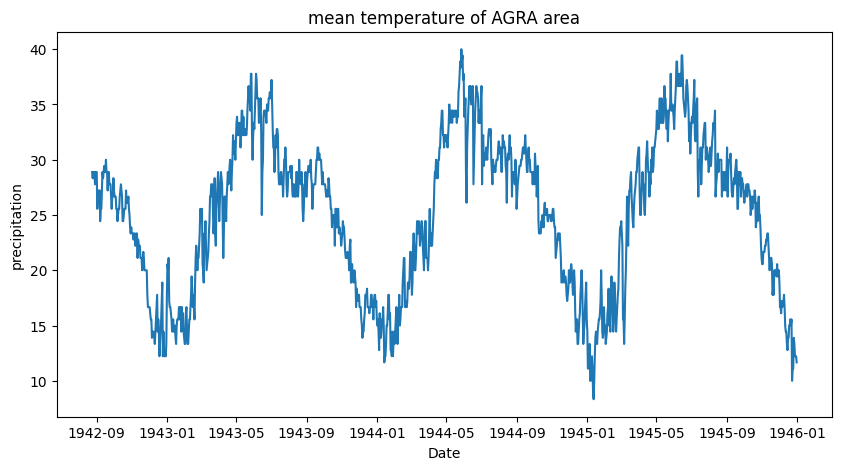

In [11]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [12]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

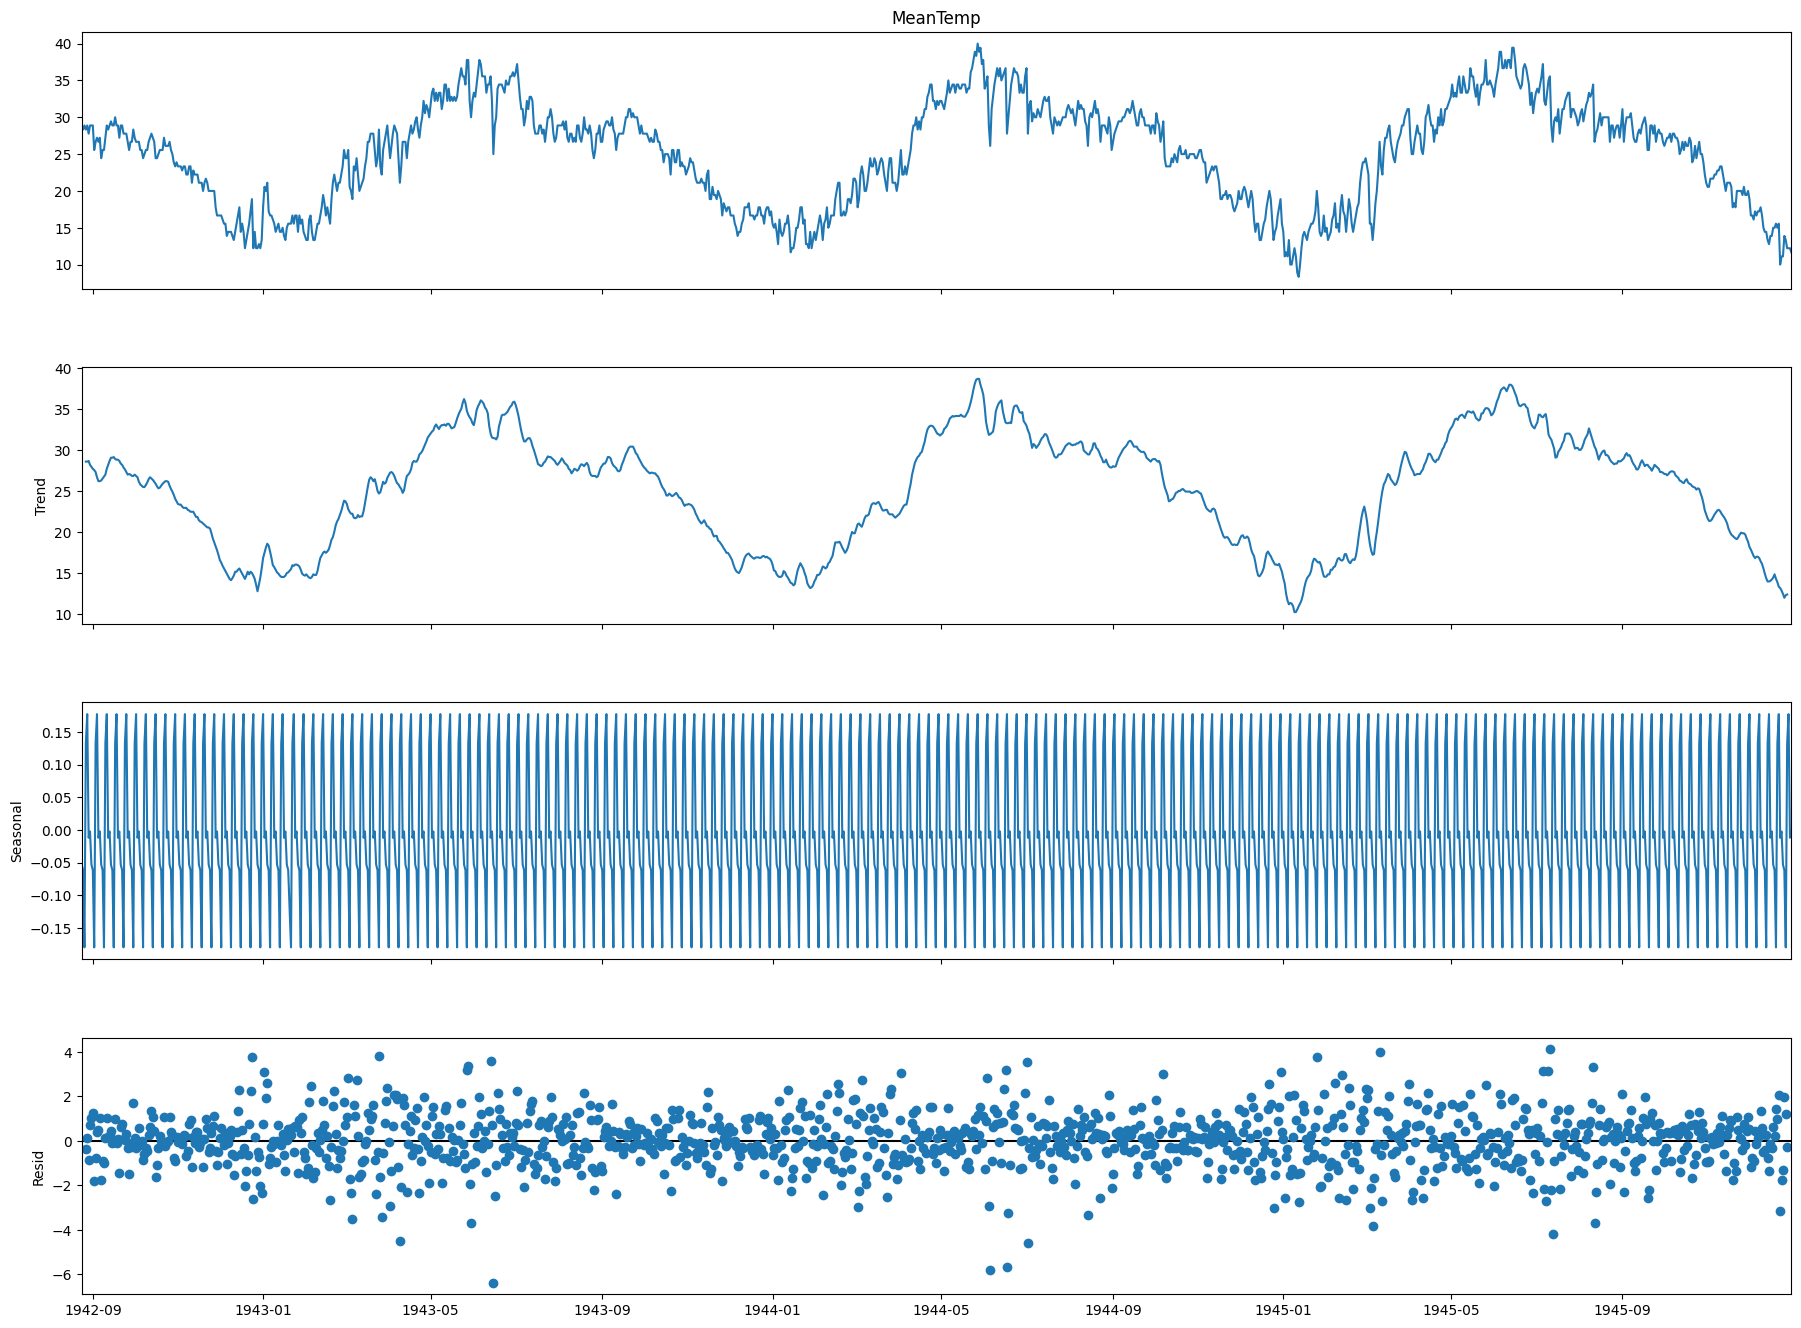

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

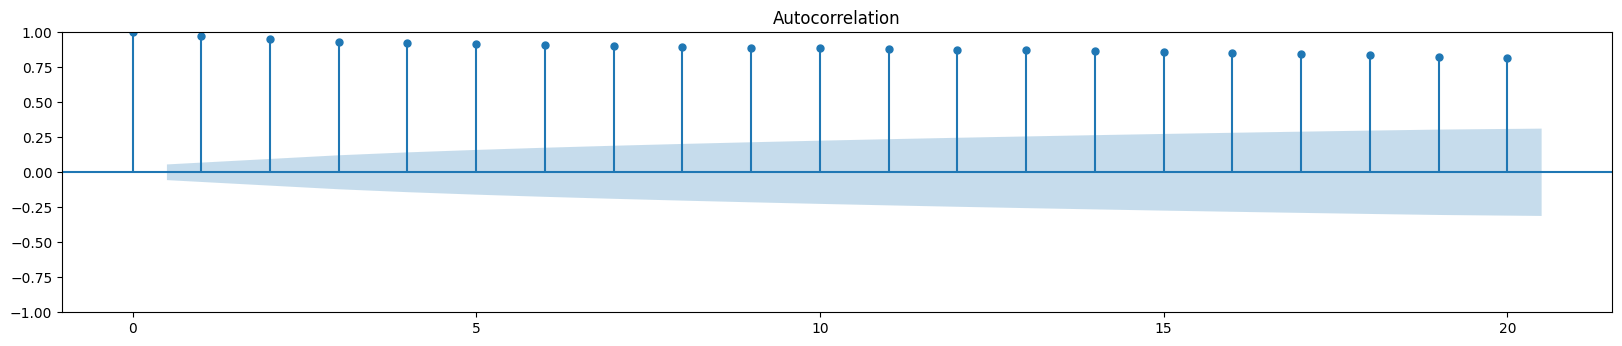

In [ ]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [14]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1. ADF 검정의 목적은 데이터에 단위근(Unit Root)이 존재하는지, 즉 비정상성을 띠는지 확인하는 것이다.

ADF 검정의 귀무가설($H_0$)는 시계열 데이터에 단위근이 존재한다. 즉, 비정상 시계열(Non-stationary)이고, p-value가 0.259885 이므로 유의수준 5%보다 훨씬 크다. 따라서 귀무가설 기각에 실패했다. 이 시계열은 비정상 시게열이다.

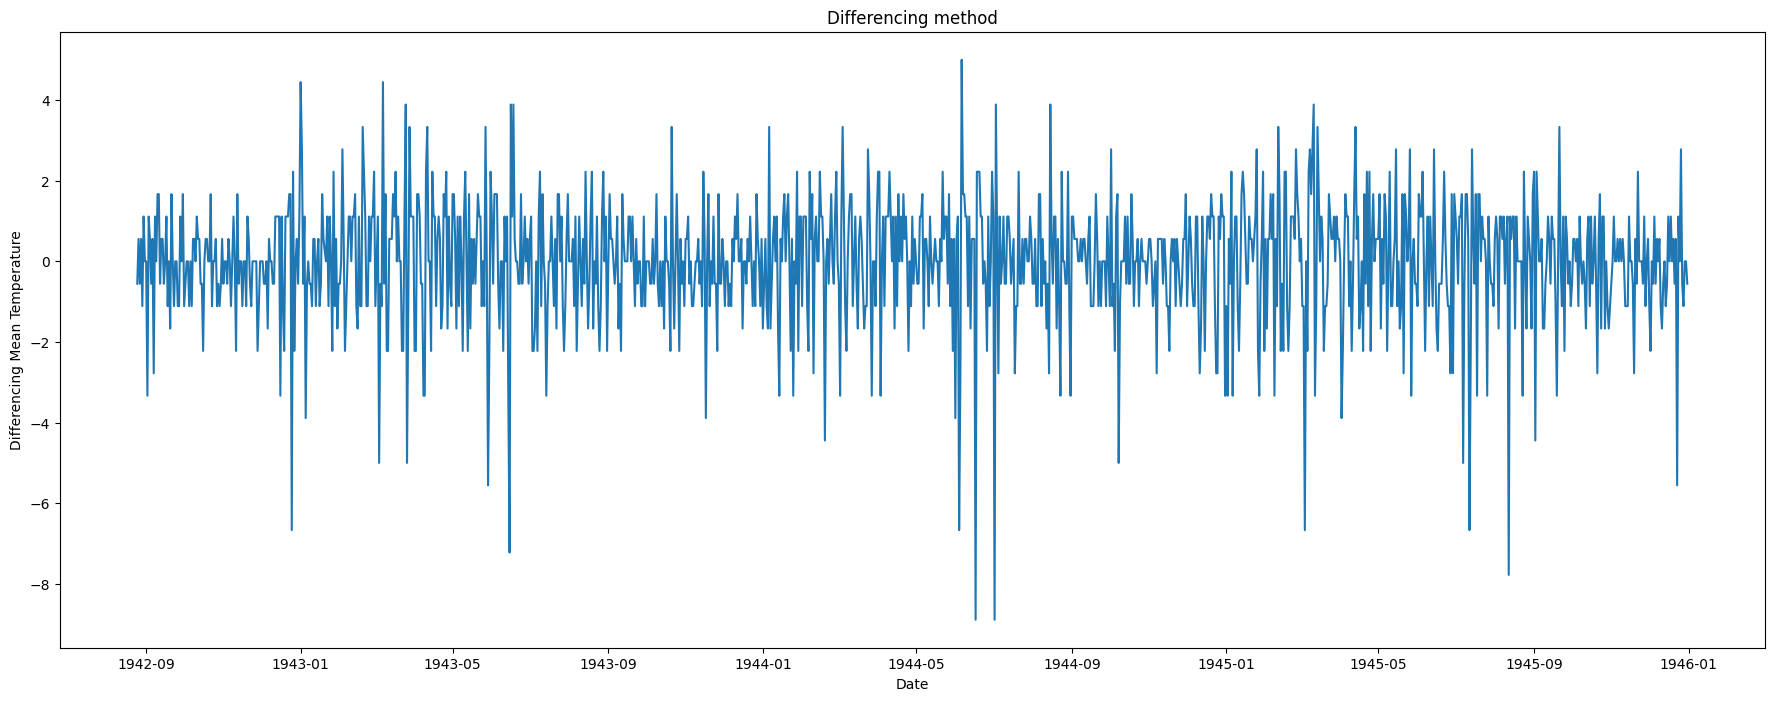

In [15]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [16]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2.

이전 결과에서는 p-value가 0.259였으나, 차분 후에는 유의수준인 0.05보다 훨씬 작은 값으로 떨어졌다. 이제 p-value < 0.05이므로 "단위근이 존재한다(비정상이다)"라는 귀무가설을 기각한다.

ADF 검정 결과가 달라진 이유는 차분(Differencing)을 통해 데이터의 추세(Trend)를 제거했기 때문이다. ts_diff는 $y_t - y_{t-1}$ 연산을 통해 절대적인 수치가 아닌 '어제 대비 얼마나 변했는가' 라는 변화량(잔차)만을 남긴다.

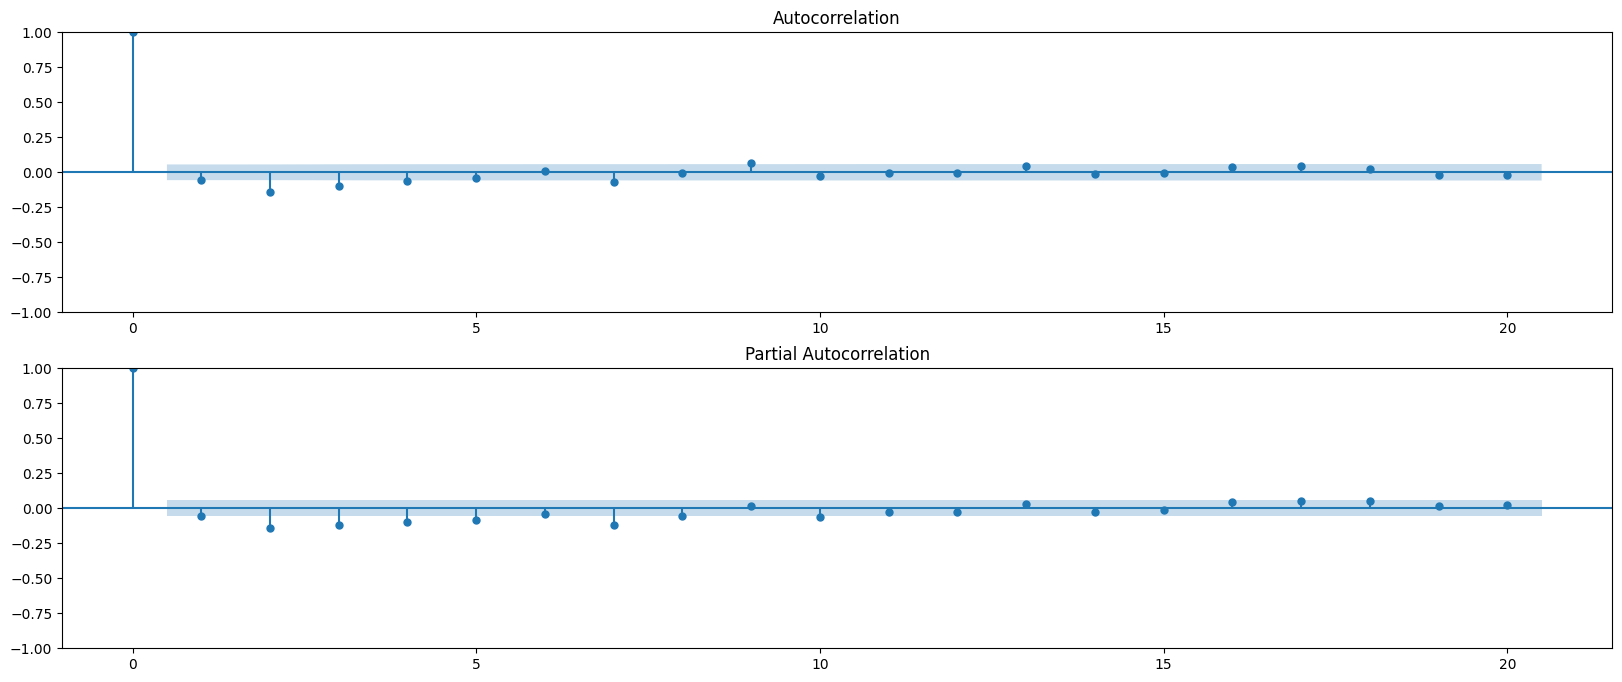

In [17]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3.

그래프를 보면 둘 다 시차 1부터 모든 막대(spike)가 파란색 음영으로 표시된 신뢰구간(Confidence Interval) 주변에 위치하고 있다.

$p = 0$: PACF 그래프에서 시차 1 이후의 모든 값이 신뢰구간 내에 존재하며 통계적으로 유의미한 상관관계를 보이지 않는다. 즉, PACF가 시차 1부터 절단(Cut-off)된 형태이므로 AR 성분이 필요 없는 $p=0$이 적절하다.

$q = 0$: ACF 그래프에서도 마찬가지로 시차 1 이후의 모든 자기상관 값이 신뢰구간 주변에 머물러 있다. ACF가 시차 1부터 절단된 형태를 보이므로 MA 성분이 필요 없는 $q=0$이 적절하다.

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


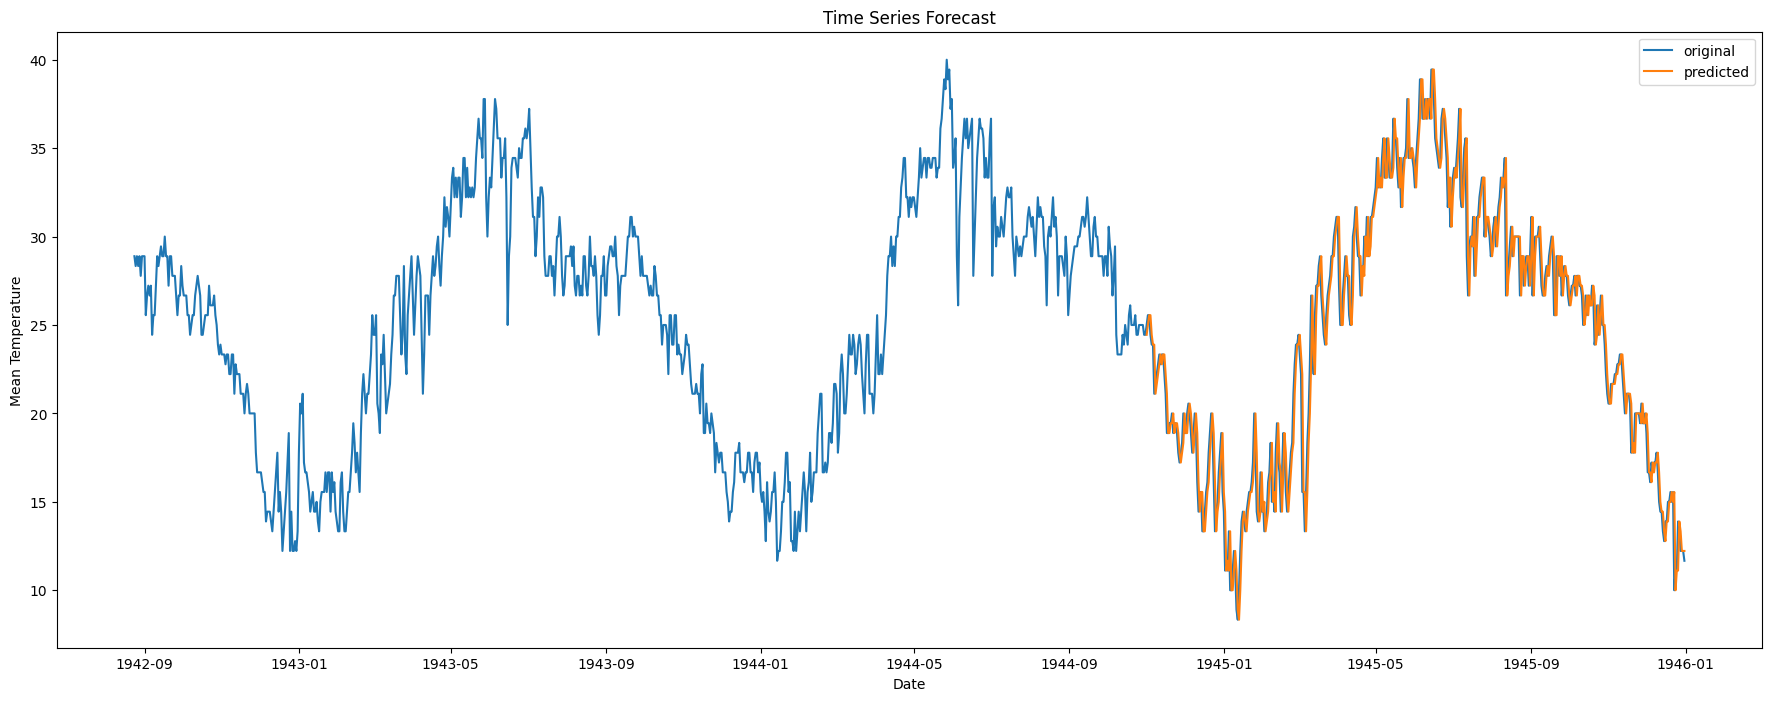

In [18]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 0
d = 1
q = 0

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_815/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


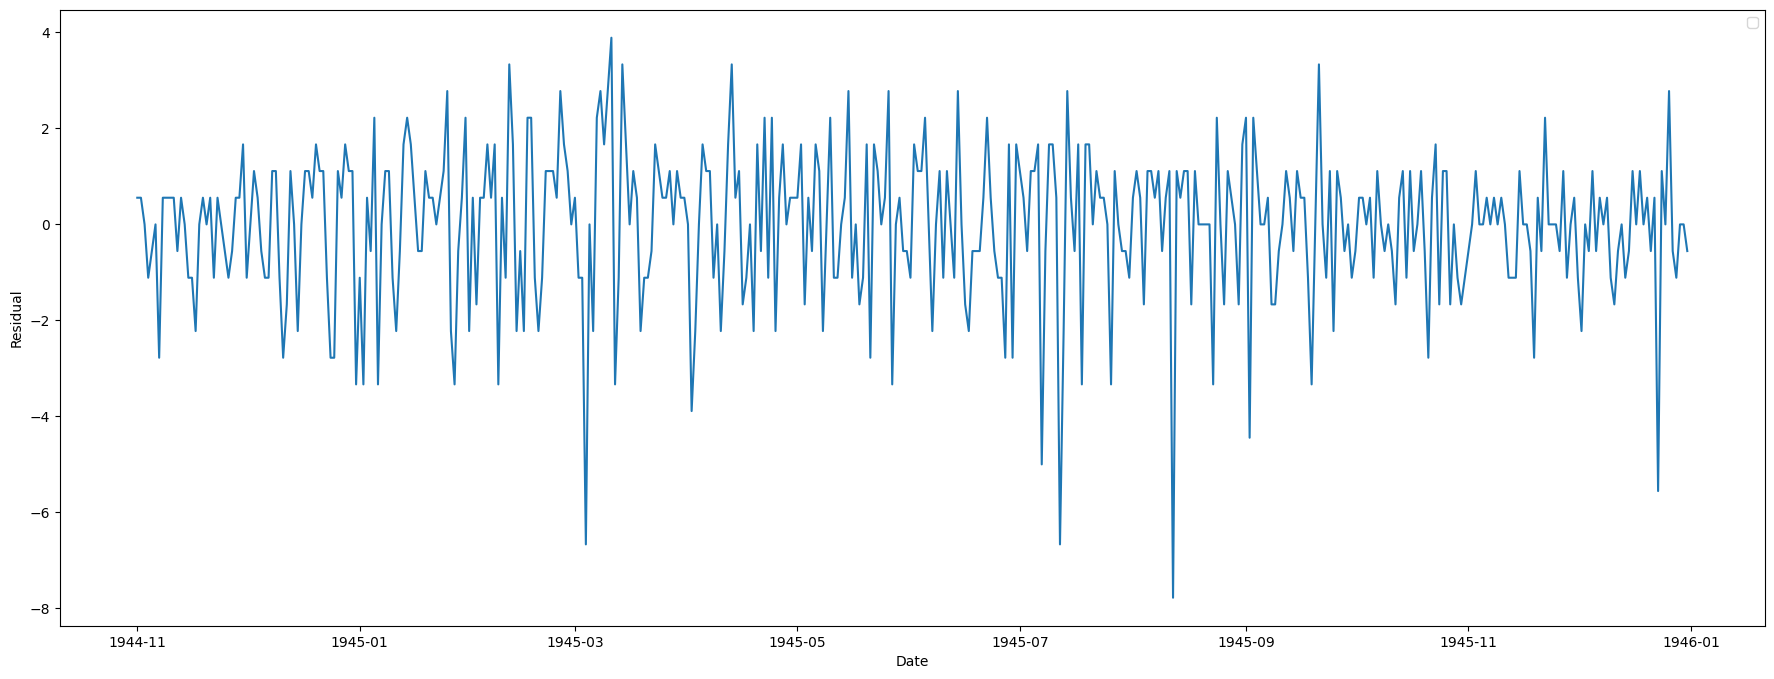

In [19]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

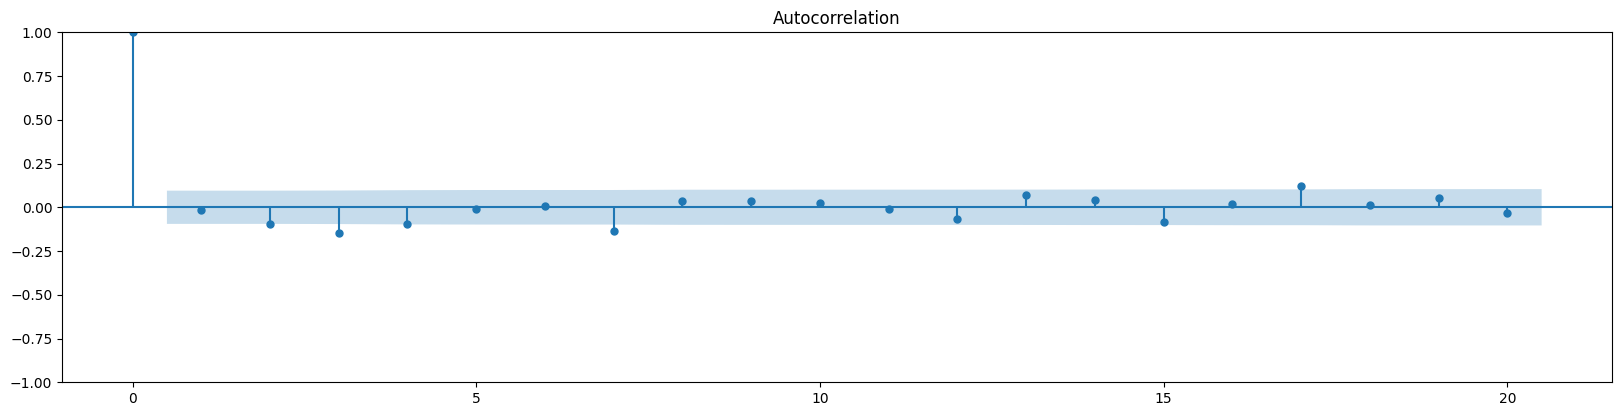

In [20]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [21]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.375983
p-value: 0.000000
Critical Values:
	1%: -3.446
	5%: -2.868
	10%: -2.570


In [22]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [23]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.56,0.978,1.565,5.366


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4.

R2 (95.589): 모델이 데이터 변동의 약 95.6%를 설명하고 있다.
Corr (0.978): 실제값과 예측값의 상관관계가 매우 높다.
MAPE (5.426): 평균 절대 비율 오차가 약 5.4%로, 기온 데이터 특성상 매우 안정적인 예측이 이루어지고 있음을 알 수 있다.

ARIMA(0, 1, 0)이라는 가장 단순한 모델임에도 불구하고 이 정도 수치가 나온다는 건, 기온 데이터의 일별 변화를 예측하는 데 있어 '오늘의 기온이 내일의 기온을 결정하는 가장 큰 요인'이라는 점이 통계적으로 증명된 셈이다.

### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.

(R^2, Corr, RMSE, MAPE)

1. 초기 상태: 69.071, 0.853, 3.84, 11.923

2. epochs=50, lr=0.001, kernel_size=25로 조정: 83.074, 0.92, 2.84, 9.265
(epoch을 늘리고, lr 조정함. kernel size를 25 정도로 설정해 한 달 주기의 흐름을 볼 수 있도록 설정)

3. epochs=100, lr=0.001, kernel_size=25로 조정: 77.523, 0.906, 3.273, 10.537
(50 이후로는 Loss 값이 더 이상 안 떨어지고 제자리걸음(수렴)을 하고 있음, epoch 늘려도 과적합 양상이 보임)

4. epochs=50, lr=0.001, kernel_size=7로 조정: 81.879, 0.933, 2.939, 9.408
(일주일 단위의 짧은 예측 시도, 실제 기온 흐름과의 상관계수(Corr)가 0.933으로 가장 높게 나타났으나 R^2 값 감소, RMSE 증가)

5. epochs=50, lr=0.001, kernel_size=51로 조정: 85.263, 0.927, 2.65, 8.511
(두 달 정도 단위의 예측, 전반적인 수치가 가장 좋게 나타남. pred_len = 30으로 한 달 주기의 예측을 목표하고 있기 때문에, 모델이 매일매일의 날씨 변화보다 계절적 흐름을 어느정도 반영할 때 수치가 좋을 것으로 예상)

6. epochs=50, lr=0.0005, kernel_size=51로 조정: 85.282, 0.94, 2.649, 8.756
(Loss 로그에서 값이 0.0034 부근 osillation을 보여줌. lr을 절반으로 줄여 수치 개선 확인)

7. epochs=50, lr=0.0005, kernel_size=51 상태에서 batch_size = 32로 조정(기존 16): 87.771	0.941	2.414	7.849


---

[결론 1]

초기 상태 (R2 69.07, RMSE 3.84): 기본 설정(epochs=10, lr=0.01, batch_size=16)에서는 학습이 충분히 이루어지지 않는 과소적합 상태를 확인함.

커널 크기(kernel_size) 최적화: 시계열 분해 시 단기 노이즈(ex. kernel_size=7)에 예민하게 반응하기보다, 약 한 달 반 주기의 거시적 계절성(Seasonality) 흐름을 추출할 수 있는 kernel_size=51을 적용했을 때 성능이 극대화됨을 확인.

학습 횟수(epochs) 및 학습률(lr) 미세 조정: 안정적인 수렴을 위해 epochs를 50으로 상향함. (100 초과 시 과적합 발생 확인). 또한 학습 후반부의 손실(Loss) 진동을 제어하기 위해 lr을 0.0005로 하향하여 지역 최솟값(Local Minimum)을 정밀하게 조정

배치 사이즈(batch_size) 튜닝: 최종적으로 16에서 32로 상향 조정하여 한 번에 처리하는 데이터의 군집도를 높임. 이는 작아진 학습률(lr)과 시너지를 내어 그래디언트 업데이트의 노이즈를 상쇄시켰으며, 그 결과 최종 R2 87.771, RMSE 2.414, MAPE 7.849라는 최고 성능 갱신을 달성함.

---
[결론 2]

해당 데이터셋에 더 적합한 모델: DLinear

ARIMA의 구조적 한계: WWII 기온 데이터 분석 시, 정상성 확보를 위한 1차 차분($d=1$) 결과 남은 잔차가 백색 잡음(White Noise) 형태인 ARIMA(0, 1, 0) 모형으로 식별됨. 이는 단기(1-step) 예측에는 유리하나 (상당히 높은 R^2 값 등을 보여줌), 본 과제의 목표인 30일 장기 연속 예측(pred_len=30) 시에는 상대적으로 성능이 떨어질 것으로 예측됨.

DLinear의 장기 예측 우위: DLinear는 이동평균 풀링(AvgPool1d) 기반의 시계열 분해(Series Decomposition)를 통해 기온의 장기 추세(Trend)와 계절성(Seasonality)을 병렬로 분리하여 학습함. (최종 하이퍼파라미터 튜닝 이후 R2 87.771)


In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [65]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [88]:
seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [89]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=51): # kernel size는 홀수만 입력으로 받는 상태
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [90]:
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

epochs = 50

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.005041
Epoch 20, Loss: 0.003768
Epoch 30, Loss: 0.003545
Epoch 40, Loss: 0.003396
Epoch 50, Loss: 0.003106


In [92]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

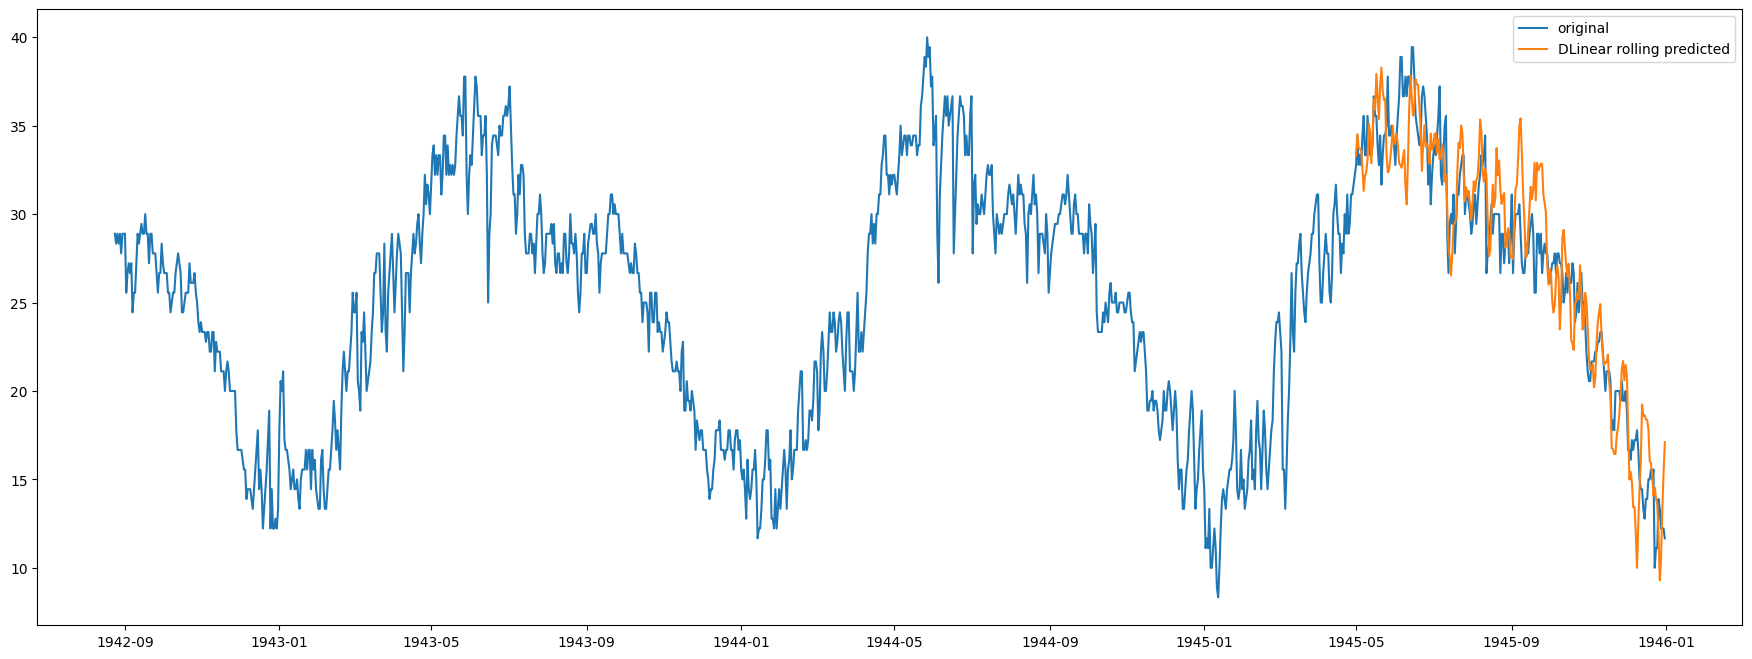

In [72]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [93]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,87.771,0.941,2.414,7.849


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [94]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
...,...
TINDOUF,818
VAL DE CANS,1188
WALLER/BWI,1631


## MAISON BLANCHE 평균 기온 시계열 분석

**1. 분석 대상 선정 및 판단 근거**
* **분석 도시:** `MAISON BLANCHE` (충분한 데이터가 확보된 도시 중 임의 선정)
* **분석 요인:** `MeanTemp` (평균 기온)
* **선정 근거:** 실습 1에서 다룬 불규칙한 패턴의 강수량(Precip)과 달리, 뚜렷한 계절성(Seasonality)과 추세(Trend)를 지닌 기온 데이터를 분석하여 두 모델(ARIMA, DLinear)의 예측 메커니즘 차이를 명확히 비교하고자 함.

In [141]:
# 1. 분석 도시 및 타겟 변수 설정
CITY_NAME = "MAISON BLANCHE"
TARGET_COL = "MeanTemp"

# 도시 이름으로 관측소 ID(WBAN) 매핑
loc_sta = loc_df[loc_df["NAME"] == CITY_NAME].WBAN.iloc[0]

# 해당 관측소 데이터 필터링 및 전처리
new_weather = weather_df[weather_df.STA == int(loc_sta)].copy()
new_weather["Date"] = pd.to_datetime(new_weather["Date"])

# 시계열 데이터셋 생성 (Date를 인덱스로 변환)
timeSeries_new = new_weather.loc[:, ["Date", TARGET_COL]].dropna()
timeSeries_new.set_index("Date", inplace=True)

display(timeSeries_new.head())

,MeanTemp
Date,
1943-04-11,14.444444
1943-04-12,15.555556
1943-04-13,14.444444
1943-04-14,15.555556
1943-04-15,12.222222


**2. 탐색적 데이터 분석 (EDA) 및 시계열 분해**
* **데이터 시각화 과정:** 결측치 제거 후 원본 시계열 데이터의 전반적인 변동성 및 주기 패턴 확인.
* **성분 분해(Decomposition):** 기온 데이터 특성상 뚜렷한 주기를 지니므로, `seasonal_decompose`를 활용하여 원본 시계열을 추세(Trend), 계절성(Seasonal), 잔차(Resid) 성분으로 명확히 분리 및 탐색함.

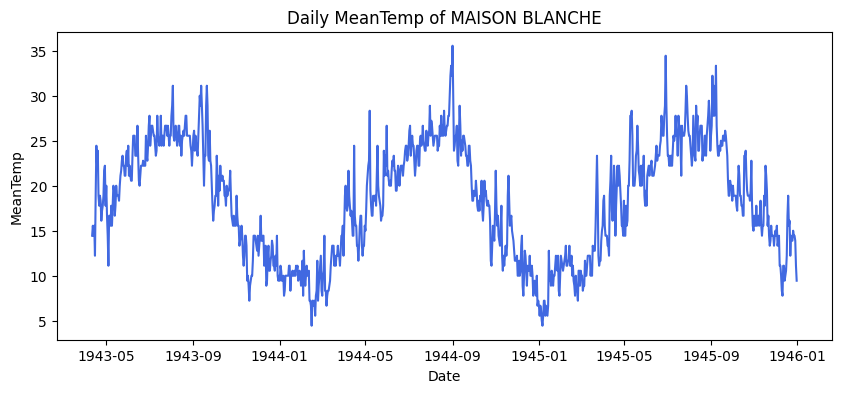

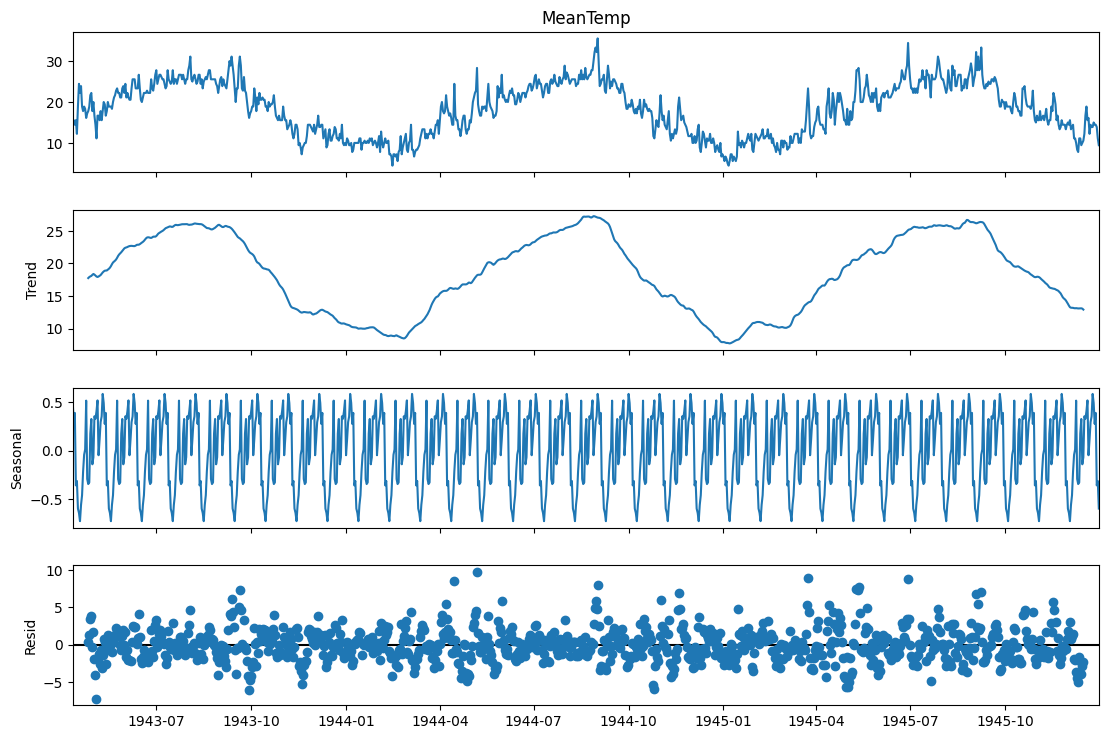

In [142]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 원본 데이터 시각화
plt.figure(figsize=(10, 4))
plt.plot(timeSeries_new.index, timeSeries_new[TARGET_COL], color='royalblue')
plt.title(f"Daily {TARGET_COL} of {CITY_NAME}")
plt.xlabel("Date")
plt.ylabel(TARGET_COL)
plt.show()

# 시계열 성분 분해 (Additive 모델, 월간/계절 주기 반영을 위해 period=30 적용)
result_new = seasonal_decompose(timeSeries_new[TARGET_COL], model='additive', period=30)
fig = result_new.plot()
fig.set_size_inches(12, 8)
plt.show()

**3. 정상성 검정 및 ARIMA 모형 적합**
* **단위근 검정(ADF Test):** p-value를 산출하여 데이터의 정상성 확보 여부 및 차분(Differencing) 필요성 진단.
* **ACF/PACF 분석:** 자기상관함수 시각화를 통해 AR(p) 및 MA(q) 모수 탐색.
* **ARIMA 훈련 및 평가:** 도출된 파라미터로 모델을 적합한 뒤, 테스트 세트에 대한 1-step 예측 수행 및 정량적 평가지표 산출.

원본 데이터 p-value: 0.3277
1차 차분 후 p-value: 0.0000


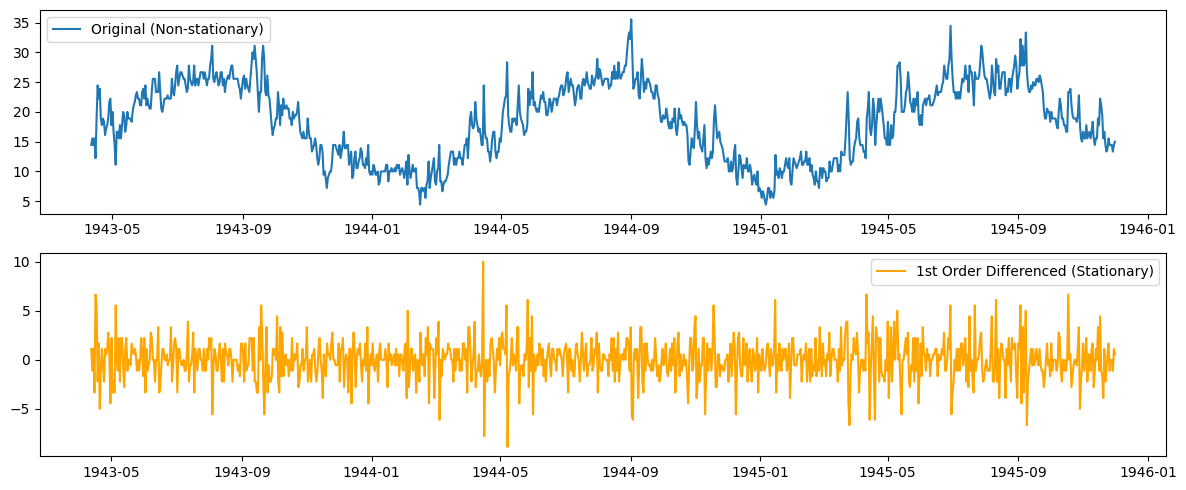

In [143]:
from statsmodels.tsa.stattools import adfuller

# 1. 원본 데이터 ADF 테스트
result_orig = adfuller(train[TARGET_COL])
print(f'원본 데이터 p-value: {result_orig[1]:.4f}')

# 2. 1차 차분 수행
train_diff = train[TARGET_COL].diff().dropna()

# 3. 차분 후 데이터 ADF 테스트 (정상성 확보 확인)
result_diff = adfuller(train_diff)
print(f'1차 차분 후 p-value: {result_diff[1]:.4f}')

# 차분 전후 비교 시각화
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(train[TARGET_COL], label='Original (Non-stationary)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(train_diff, label='1st Order Differenced (Stationary)', color='orange')
plt.legend()
plt.tight_layout()
plt.show()

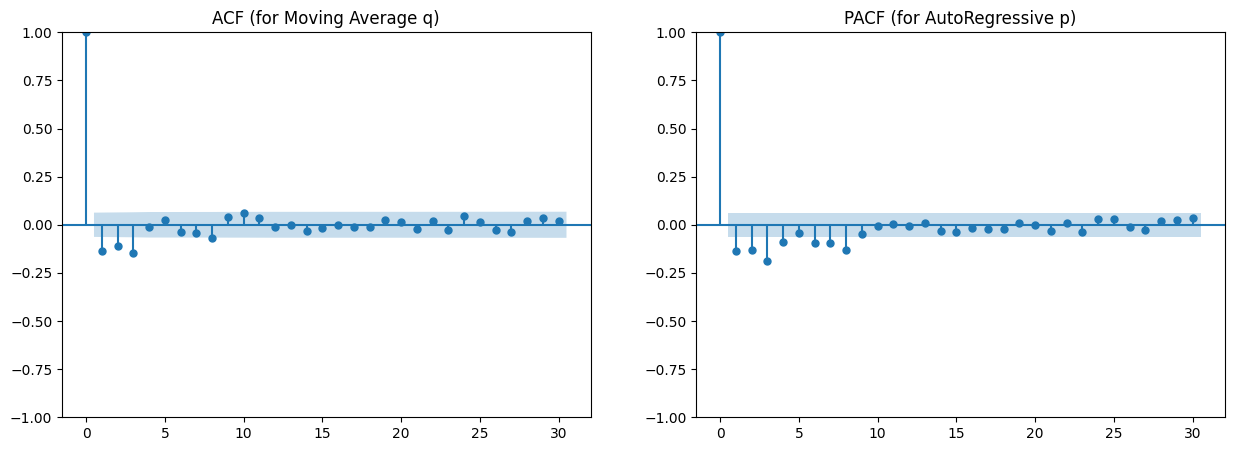

In [144]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 차분된 데이터를 넣어서 그래프를 그리기
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ACF: q(MA)
plot_acf(train_diff, ax=ax[0])
ax[0].set_title('ACF (for Moving Average q)')

# PACF: p(AR)
plot_pacf(train_diff, ax=ax[1])
ax[1].set_title('PACF (for AutoRegressive p)')

plt.show()

In [146]:
from statsmodels.tsa.arima.model import ARIMA

# 결정된 모수 설정
p, d, q = 0, 1, 0

# 모델 정의 및 학습
arima_model = ARIMA(train[TARGET_COL], order=(p, d, q))
arima_result = arima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



[ARIMA 최종 성능 지표]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,R2,Corr,RMSE,MAPE
0,-69.914,NaN,3.407,25.381


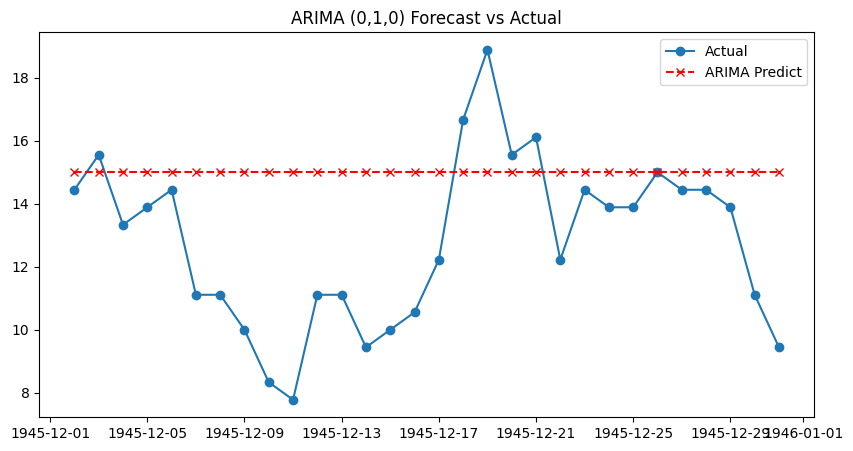

In [147]:
# 1. 미래 30일 예측 (typ='levels'를 통해 실제 기온 단위로 복원)
arima_pred = arima_result.predict(start=len(train), end=len(timeSeries_new)-1, typ='levels')

# 2. 성능 평가 (기존 scoring 함수 활용)
print("\n[ARIMA 최종 성능 지표]")
arima_scores = scoring(test[TARGET_COL].values, arima_pred.values)
display(arima_scores)

# 3. 예측 결과 시각화 (Dlinear와 동일하게 30일 예측)
plt.figure(figsize=(10, 5))
plt.plot(test.index, test[TARGET_COL], label='Actual', marker='o')
plt.plot(test.index, arima_pred, label='ARIMA Predict', marker='x', linestyle='--', color='red')
plt.title(f'ARIMA ({p},{d},{q}) Forecast vs Actual')
plt.legend()
plt.show()

**4. DLinear 모형 구축 및 장기 예측 (Multi-step)**
* **스케일링 및 데이터셋 구성:** 손실값의 안정적 수렴을 위해 MinMax 정규화 적용. 과거 365일(`seq_len`)을 기반으로 미래 30일(`pred_len`) 구간을 한 번에 예측하도록 DataLoader 형태 변환.
* **하이퍼파라미터 최적화 적용:** 변덕스러운 지중해성 기후의 지역이므로 단기적인 경향성 기반의 예측이 성능이 좋을 것으로 예측. `kernel_size=7` (날씨 변화가 크므로 짧게 학습) 및 과적합 방지를 고려한 `epochs=70`, `lr=0.0001`, `batch_size=32` (직전 실습에서 낮은 lr, 높은 batch size의 효과가 좋았음)를 최종 파라미터로 확정하여 학습 진행.

--- MAISON BLANCHE 학습 시작 (Window: 365) ---
Epoch 10, Loss: 0.017183
Epoch 20, Loss: 0.010390
Epoch 30, Loss: 0.009193
Epoch 40, Loss: 0.008759
Epoch 50, Loss: 0.008291
Epoch 60, Loss: 0.007879
Epoch 70, Loss: 0.007535

[MAISON BLANCHE] 최종 성능 지표 (DLinear_2)


,R2,Corr,RMSE,MAPE
0,67.009,0.877,3.185,12.322


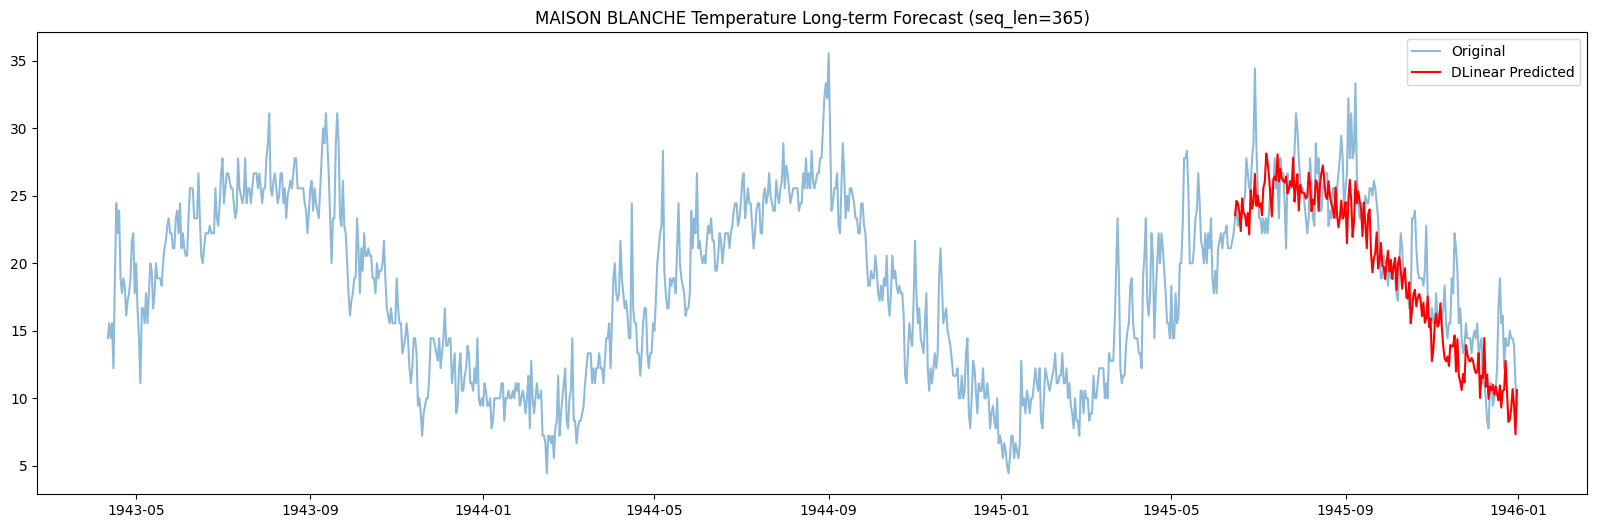

In [148]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. 하이퍼파라미터 및 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len_2 = 365  # 과거 참조 기간
pred_len_2 = 30  # 미래 예측 기간
batch_size_2 = 32
lr_2 = 0.0001
epochs_2 = 70

# 2. 데이터 전처리 (MAISON BLANCHE 대상)
# timeSeries_new는 이전에 생성한 MAISON BLANCHE 데이터프레임 사용
data_2 = timeSeries_new.values

train_size_2 = int(len(data_2) * 0.8)
train_data_2 = data_2[:train_size_2]
test_data_2 = data_2[train_size_2:]

scaler_2 = MinMaxScaler()
train_scaled_2 = scaler_2.fit_transform(train_data_2)
test_scaled_2 = scaler_2.transform(test_data_2)

# 3. Dataset 클래스
class TimeSeriesDataset_2(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len
  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len
  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset_2 = TimeSeriesDataset_2(train_scaled_2, seq_len_2, pred_len_2)
train_loader_2 = DataLoader(train_dataset_2, batch_size=batch_size_2, shuffle=True)

# 4. DLinear 모델 정의
class DLinear_2(nn.Module):
  def __init__(self, slen, plen, k_size=7):
    super().__init__()
    self.moving_avg = nn.AvgPool1d(kernel_size=k_size, stride=1, padding=k_size//2)
    self.linear_seasonal = nn.Linear(slen, plen)
    self.linear_trend = nn.Linear(slen, plen)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

# 모델 객체 새로 생성
model_2 = DLinear_2(seq_len_2, pred_len_2).to(device)
criterion_2 = nn.MSELoss()
optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=lr_2)

# 5. 학습 진행
print(f"--- {CITY_NAME} 학습 시작 (Window: {seq_len_2}) ---")
for epoch in range(epochs_2):
  model_2.train()
  total_loss = 0
  for x, y in train_loader_2:
    x, y = x.to(device), y.to(device)
    optimizer_2.zero_grad()
    output = model_2(x)
    loss = criterion_2(output, y.squeeze(-1))
    loss.backward()
    optimizer_2.step()
    total_loss += loss.item()
  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader_2):.6f}")

# 6. Walk-Forward Validation 예측
model_2.eval()
predictions_2 = []
current_window_2 = train_scaled_2[-seq_len_2:].copy()
total_test_len_2 = len(test_scaled_2)

while len(predictions_2) < total_test_len_2:
  x_2 = torch.tensor(current_window_2, dtype=torch.float32).unsqueeze(0).to(device)
  with torch.no_grad():
    pred_2 = model_2(x_2).cpu().numpy().flatten()

  remaining_2 = total_test_len_2 - len(predictions_2)
  pred_2 = pred_2[:remaining_2]
  predictions_2.extend(pred_2)

  # 윈도우 업데이트
  current_window_2 = np.concatenate([current_window_2[len(pred_2):], pred_2.reshape(-1,1)], axis=0)

# 역정규화 및 성능 평가
forecast_dl_2 = scaler_2.inverse_transform(np.array(predictions_2).reshape(-1,1))
actual_2 = test_data_2.flatten()

print(f"\n[{CITY_NAME}] 최종 성능 지표 (DLinear_2)")
display(scoring(actual_2, forecast_dl_2.flatten()))

# 7. 시각화
plt.figure(figsize=(20, 6))
plt.plot(timeSeries_new.index, timeSeries_new.values, label="Original", alpha=0.5)
test_dates_2 = timeSeries_new.index[train_size_2:]
plt.plot(test_dates_2, forecast_dl_2.flatten(), label="DLinear Predicted", color='red')
plt.title(f"{CITY_NAME} Temperature Long-term Forecast (seq_len={seq_len_2})")
plt.legend()
plt.show()

[최종 결과 분석 및 비교]

1. 분석 결과 요약

도시 및 요인: MAISON BLANCHE / MeanTemp (평균 기온)

예측 방식: 30일 장기 멀티스텝 예측 (Multi-step Forecast)

모델별 성능 비교:

| 모델 | $R^2$ (결정계수) | Corr (상관계수) | RMSE | MAPE |
| :--- | :---: | :---: | :---: | :---: |
| DLinear | 67.009 | 0.877 | 3.185 | 12.322 |
| ARIMA | -69.914 | NaN | 3.407 | 25.381 |

2. ARIMA 성능 지표의 의미 해석 (왜 NaN과 음수가 나왔는가?)

Corr(상관계수) NaN의 의미: 상관계수는 두 변수의 변화 방향이 얼마나 일치하는지 측정함. ARIMA의 예측값이 시각적으로 완벽한 직선(Flat line)으로 나타나 분산이 0이 됨에 따라 수학적으로 상관계수 산출이 불가능(NaN)해진 것임.

음수 $R^2$의 의미: ARIMA 모델이 기온의 계절적 하락/상승 곡선을 전혀 추종하지 못하고 단순히 과거 평균 근처에 머물렀음을 의미함.

이는 단순 평균 모델보다도 성능이 낮음을 뜻하며, 기상 데이터의 장기 예측에서 ARIMA의 한계를 극명하게 보여줌.

3. 기존 실습 (AGRA)과 추가 실습(MAISON BLANCHE)의 결정적 차이

기존 실습 에서는 인샘플(In-sample) 예측 또는 1-step 예측 위주로 수행되어 $R^2$가 90% 이상의 높은 수치를 기록함. 이는 모델이 '정답을 어느 정도 알고 있는' 상태에서의 평가임.

(기존 실습은 model = ARIMA(ts, order=(0,1,0))로 진행했으며 여기서 ts는 전체 데이터임)

본 추가 실습에서는 미래 30일 구간을 완전히 격리한 뒤, 이전 정보 없이 오직 모델의 예측력만으로 밀고 나가는 진정한 의미의 Out-of-sample 예측을 수행함.

동일한 환경에서 ARIMA는 직선을 그리며 무너진 반면, DLinear는 시계열 분해(Decomposition)를 통해 기온의 계절적 리듬을 스스로 그려내며 67.0의 높은 $R^2$와 0.877의 높은 상관계수를 기록함.

4. 최종 결론 및 인사이트

기상 데이터 분석의 핵심: 기온과 같이 뚜렷한 계절성(Seasonality)을 지닌 데이터의 장기 예측에는 단순 통계 모델인 ARIMA보다, 추세와 계절성을 분리하여 학습하는 DLinear와 같은 신경망 기반 분해 모델이 압도적으로 유리함.

다만, ARIMA의 모델 구조적인 한계상 30일 예측은 데이터가 적고 단기적인 예측이 유리한 ARIMA의 목적에 맞지 않을 가능성이 높기 때문에 DLinear가 항상 좋은 예측 방식이라는 결론을 내리기에는 무리가 있다.